In [1]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import os, glob
import cv2
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

PART 1 extract_face_features

In [2]:
data_root = "/Users/teemtat/Documents/MUICT/RESEARCH/NEW/data"

In [3]:
def detect_face_mesh_xyz(image_bgr,
                          max_num_faces=1,
                          static_image_mode=True,
                          refine_landmarks=True,
                          min_det_conf=0.6,
                          min_track_conf=0.6):

    h, w = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    mp_face_mesh = mp.solutions.face_mesh

    faces_xyz = []

    with mp_face_mesh.FaceMesh(
        static_image_mode=static_image_mode,
        max_num_faces=max_num_faces,
        refine_landmarks=refine_landmarks,
        min_detection_confidence=min_det_conf,
        min_tracking_confidence=min_track_conf
    ) as mesh:

        results = mesh.process(image_rgb)

        if not results.multi_face_landmarks:
            return faces_xyz

        for face_landmarks in results.multi_face_landmarks:
            pts = np.zeros((len(face_landmarks.landmark), 3), dtype=np.float32)

            for i, lm in enumerate(face_landmarks.landmark):
                x = lm.x * w
                y = lm.y * h
                z = lm.z
                pts[i] = [x, y, z]

            faces_xyz.append(pts)

    return faces_xyz
# 2D 3D Visualization (Point Cloud)
def draw_landmarks_2d(image, faces_xyz, r=1):
    vis = image.copy()
    h, w = vis.shape[:2]

    for face in faces_xyz:
        for x, y, z in face:
            xi = int(x)
            yi = int(y)
            if 0 <= xi < w and 0 <= yi < h:
                cv2.circle(vis, (xi, yi), r, (0,255,0), -1)

    return vis
def show_pointcloud_3d(face_xyz):

    xs = face_xyz[:,0]
    ys = face_xyz[:,1]
    zs = face_xyz[:,2]

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(xs, ys, zs, s=2)

    ax.set_title("3D Face Landmark Point Cloud")

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z (relative depth)")

    # ให้หมุนดูง่าย
    ax.view_init(elev=20, azim=60)

    plt.show()
def show_pointcloud_3d_interactive(face_xyz):
    xs = face_xyz[:, 0]
    ys = face_xyz[:, 1]
    zs = face_xyz[:, 2]

    fig = go.Figure(data=[
        go.Scatter3d(
            x=xs, y=ys, z=zs,
            mode="markers",
            marker=dict(size=2)
        )
    ])

    fig.update_layout(
        title="3D Face Landmark Point Cloud (interactive)",
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z"
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

num faces: 1
Landmarks shape: (478, 3)


I0000 00:00:1771588882.428140  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1771588882.430256  211849 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588882.434542  211851 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


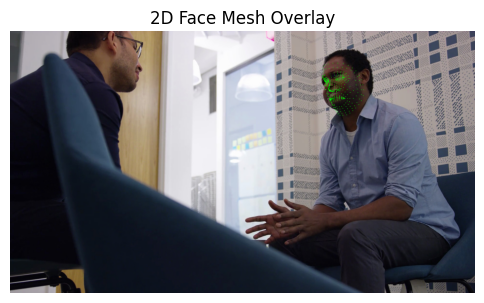

In [4]:
# MAIN
if __name__ == "__main__":
    img_path = "/Users/teemtat/Documents/MUICT/RESEARCH/NEW/MN DATA/train/fake/secret_conversation__t0001__fake.jpg"
    img = cv2.imread(img_path)

    if img is None:
        raise FileNotFoundError("Image not found!")

    faces_xyz = detect_face_mesh_xyz(
        img,
        max_num_faces=2,
        static_image_mode=True,
        refine_landmarks=True,
        min_det_conf=0.3,
        min_track_conf=0.1
    )

    print("num faces:", len(faces_xyz))
    if len(faces_xyz) == 0:
        print("No face detected — try another image or lower min_det_conf more.")
        raise SystemExit
    
    print("Landmarks shape:", faces_xyz[0].shape)

    # 2D display / in notebook
    vis2d = draw_landmarks_2d(img, faces_xyz)
    vis_rgb = cv2.cvtColor(vis2d, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,8))
    plt.imshow(vis_rgb)
    plt.axis("off")
    plt.title("2D Face Mesh Overlay")
    plt.show()

    # 3D display
    # show_pointcloud_3d(faces_xyz[0])
    show_pointcloud_3d_interactive(faces_xyz[0])


In [5]:
def _safe_skew(x):
    # skew = E[(x-μ)^3] / σ^3
    mu = x.mean()
    sigma = x.std()
    if sigma == 0:
        return 0.0
    return np.mean(((x - mu) / sigma) ** 3)

def _safe_kurtosis_excess(x):
    # excess kurtosis = E[(x-μ)^4]/σ^4 - 3
    mu = x.mean()
    sigma = x.std()
    if sigma == 0:
        return -3.0
    return np.mean(((x - mu) / sigma) ** 4) - 3.0

def _pca_eigs(xyz):
    # xyz: (N,3) assume centered already
    C = np.cov(xyz.T, bias=True)  # (3,3)
    eigvals = np.linalg.eigvalsh(C)  # sorted ascending
    eigvals = np.sort(eigvals)[::-1]  # descending: λ1>=λ2>=λ3
    return eigvals

def extract_face_features(face_xyz_norm):
    """
    face_xyz_norm: (N,3) centered + normalized (your 'face' variable)
    returns: 1D feature vector + feature names
    """
    xyz = face_xyz_norm.astype(np.float64)
    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]

    # --- Z stats ---
    z_mean = z.mean()
    z_std  = z.std()
    z_min  = z.min()
    z_max  = z.max()
    z_rng  = z_max - z_min
    z_p10, z_p50, z_p90 = np.percentile(z, [10, 50, 90])
    z_skew = _safe_skew(z)
    z_kurt = _safe_kurtosis_excess(z)

    # --- radial stats (distance from origin) ---
    r = np.linalg.norm(xyz, axis=1)
    r_mean = r.mean()
    r_std  = r.std()
    r_p10, r_p50, r_p90 = np.percentile(r, [10, 50, 90])

    # --- PCA shape ---
    eigs = _pca_eigs(xyz)  # [λ1,λ2,λ3]
    l1, l2, l3 = eigs
    eps = 1e-12
    pca_l2_l1 = l2 / (l1 + eps)
    pca_l3_l1 = l3 / (l1 + eps)
    pca_l3_l2 = l3 / (l2 + eps)

    # --- symmetry error (mirror across X=0) ---
    # mirror: (x,y,z) -> (-x,y,z), then for each mirrored point, find closest real point distance
    # (fast version uses brute force; ok for 468, later we can upgrade to KD-tree)
    xyz_m = xyz.copy()
    xyz_m[:, 0] = -xyz_m[:, 0]

    # pairwise distances: (N,N) = sqrt(sum((a-b)^2))
    # N=468 => ~219k distances => ยังโอเค
    diff = xyz_m[:, None, :] - xyz[None, :, :]
    dists = np.sqrt(np.sum(diff * diff, axis=2))
    nn = dists.min(axis=1)

    sym_mean = nn.mean()
    sym_std  = nn.std()
    sym_max  = nn.max()
    sym_p90  = np.percentile(nn, 90)

    feats = np.array([
        z_mean, z_std, z_min, z_max, z_rng, z_p10, z_p50, z_p90, z_skew, z_kurt,
        r_mean, r_std, r_p10, r_p50, r_p90,
        l1, l2, l3, pca_l2_l1, pca_l3_l1, pca_l3_l2,
        sym_mean, sym_std, sym_max, sym_p90
    ], dtype=np.float64)

    names = [
        # Depth (Z-axis) Statistics : ความลึกของใบหน้า
        "z_mean","z_std","z_min","z_max","z_range","z_p10","z_p50","z_p90","z_skew","z_kurt_excess",

        # Radial (Distance) Statistics : การกระจายจุดจากศูนย์กลางใบหน้า
        "r_mean","r_std","r_p10","r_p50","r_p90",

        # Global Shape (PCA-based Features) : รูปทรงรวมของ point cloud ใบหน้า
        "pca_l1","pca_l2","pca_l3","pca_l2_l1","pca_l3_l1","pca_l3_l2",

        # Facial Symmetry (Nearest-Neighbor Error) : ความไม่สมมาตรของใบหน้า
        "sym_nn_mean","sym_nn_std","sym_nn_max","sym_nn_p90"
    ]

    return feats, names

In [6]:
def normalize_face_xyz(face_xyz):
    face = face_xyz.copy()
    face -= face.mean(axis=0)                 # center
    face[:,1] *= -1                           # flip Y
    face /= np.linalg.norm(face, axis=1).max()# normalize scale
    return face

In [7]:
face_norm = normalize_face_xyz(faces_xyz[0])

feats, names = extract_face_features(face_norm)   # face = point cloud normalized ของคุณ
print(len(feats), feats[:5])


25 [-1.52588904e-11  1.07922018e-04 -1.58165116e-04  4.20038501e-04
  5.78203617e-04]


In [8]:
def build_dataset(root_dir, split="train"):
    """
    root_dir = ".../data"
    split = "train" or "val"
    """
    X, y = [], []
    stats = {"total": 0, "no_face": 0, "used": 0}

    for label, cls in [(0, "real"), (1, "fake")]:
        folder = os.path.join(root_dir, split, cls)
        for img_path in glob.glob(os.path.join(folder, "*.jpg")):
            stats["total"] += 1
            img = cv2.imread(img_path)
            if img is None:
                continue

            faces_xyz = detect_face_mesh_xyz(
                img,
                max_num_faces=1,
                static_image_mode=True,
                min_det_conf=0.3,
                min_track_conf=0.3
            )

            if len(faces_xyz) == 0:
                stats["no_face"] += 1
                continue

            face_norm = normalize_face_xyz(faces_xyz[0])
            feats, names = extract_face_features(face_norm)

            X.append(feats)
            y.append(label)
            stats["used"] += 1

    print(f"[{split}] total={stats['total']} used={stats['used']} no_face={stats['no_face']}")
    return np.vstack(X), np.array(y), names

In [9]:
X_train, y_train, feat_names = build_dataset(data_root, split="train")
X_val,   y_val,   _          = build_dataset(data_root, split="val")

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)

I0000 00:00:1771588882.757169  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588882.757890  211866 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588882.761798  211864 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning:

SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.

I0000 00:00:1771588882.775244  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588882.775916  211876 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disa

[train] total=858 used=644 no_face=214


I0000 00:00:1771588899.698298  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588899.699146  220645 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588899.702474  220643 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588899.713595  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588899.714475  220656 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588899.717150  220655 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588899.727921  211693 gl_context

[val] total=270 used=126 no_face=144
Train: (644, 25) (644,)
Val  : (126, 25) (126,)


I0000 00:00:1771588904.244316  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588904.245157  223298 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588904.248497  223300 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588904.265601  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588904.266455  223308 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588904.269546  223307 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588904.288145  211693 gl_context

In [10]:
# RandomForest
clf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    n_jobs=-1,
    max_depth=8,
    min_samples_leaf=3
)

clf.fit(X_train, y_train)

pred = clf.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred, digits=4))

print("n_features =", X_train.shape[1])
print("len(feat_names) =", len(feat_names))

# top 10 feature
imp = pd.Series(clf.feature_importances_, index=feat_names)
print(imp.sort_values(ascending=False).head(10))


[[22 41]
 [20 43]]
              precision    recall  f1-score   support

           0     0.5238    0.3492    0.4190        63
           1     0.5119    0.6825    0.5850        63

    accuracy                         0.5159       126
   macro avg     0.5179    0.5159    0.5020       126
weighted avg     0.5179    0.5159    0.5020       126

n_features = 25
len(feat_names) = 25
z_max         0.074954
pca_l3_l2     0.071685
r_p50         0.062128
z_range       0.058319
sym_nn_p90    0.046994
pca_l1        0.046461
pca_l2_l1     0.043353
r_p10         0.042813
pca_l3_l1     0.037337
z_std         0.035985
dtype: float64


In [11]:
# LinearSVC
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C = 0.2, class_weight="balanced", random_state=42))
])

clf.fit(X_train, y_train)
pred = clf.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred, digits=4))
print("Accuracy:", accuracy_score(y_val, pred))

print("n_features =", X_train.shape[1])
print("len(feat_names) =", len(feat_names))


[[20 43]
 [22 41]]
              precision    recall  f1-score   support

           0     0.4762    0.3175    0.3810        63
           1     0.4881    0.6508    0.5578        63

    accuracy                         0.4841       126
   macro avg     0.4821    0.4841    0.4694       126
weighted avg     0.4821    0.4841    0.4694       126

Accuracy: 0.48412698412698413
n_features = 25
len(feat_names) = 25


/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul



PART 2 extract_region_depth_features

In [12]:
def region_masks_from_geometry(face_norm):
    """
    face_norm: (N,3) centered + flipped Y + normalized
    returns dict region_name -> boolean mask
    """
    x = face_norm[:,0]
    y = face_norm[:,1]

    # ใช้ percentile ให้ robust
    y_hi = np.percentile(y, 65)   # ส่วนบน
    y_lo = np.percentile(y, 35)   # ส่วนล่าง

    # แบ่งซ้าย/ขวา
    x_left  = np.percentile(x, 35)
    x_right = np.percentile(x, 65)

    # ส่วนกลาง (จมูก/กลางหน้า): ใกล้ origin
    r_xy = np.sqrt(x*x + y*y)
    center_thr = np.percentile(r_xy, 20)

    masks = {
        "nose_center": (r_xy <= center_thr),
        "upper_face":  (y >= y_hi),
        "lower_face":  (y <= y_lo),
        "left_face":   (x <= x_left),
        "right_face":  (x >= x_right),
    }
    return masks

In [13]:
def z_stats(z):
    z_mean = z.mean()
    z_std  = z.std()
    z_rng  = z.max() - z.min()
    z_p10, z_p90 = np.percentile(z, [10, 90])
    return [z_mean, z_std, z_rng, z_p10, z_p90]

def extract_region_depth_features(face_norm):
    masks = region_masks_from_geometry(face_norm)
    z = face_norm[:,2]

    feats = []
    names = []

    for region, m in masks.items():
        if np.sum(m) < 10:  # กันกรณี mask น้อยเกิน
            continue

        stats = z_stats(z[m])
        feats.extend(stats)
        names.extend([
            f"{region}_z_mean",
            f"{region}_z_std",
            f"{region}_z_range",
            f"{region}_z_p10",
            f"{region}_z_p90",
        ])

    return np.array(feats, dtype=np.float64), names

In [14]:
def extract_face_features_v2(face_norm):
    # base_feats, base_names = extract_face_features(face_norm)
    reg_feats, reg_names = extract_region_depth_features(face_norm)

    # feats = np.concatenate([base_feats, reg_feats])
    feats = np.concatenate([reg_feats])
    names = reg_names
    return feats, names

In [15]:
feats, names = extract_face_features_v2(face_norm)

print(len(feats))
print(names[:10], "...", names[-10:])

25
['nose_center_z_mean', 'nose_center_z_std', 'nose_center_z_range', 'nose_center_z_p10', 'nose_center_z_p90', 'upper_face_z_mean', 'upper_face_z_std', 'upper_face_z_range', 'upper_face_z_p10', 'upper_face_z_p90'] ... ['left_face_z_mean', 'left_face_z_std', 'left_face_z_range', 'left_face_z_p10', 'left_face_z_p90', 'right_face_z_mean', 'right_face_z_std', 'right_face_z_range', 'right_face_z_p10', 'right_face_z_p90']


In [16]:
def build_dataset(root_dir, split="train"):
    """
    root_dir = ".../data"
    split = "train" or "val"
    """
    X, y = [], []
    stats = {"total": 0, "no_face": 0, "used": 0}

    for label, cls in [(0, "real"), (1, "fake")]:
        folder = os.path.join(root_dir, split, cls)
        for img_path in glob.glob(os.path.join(folder, "*.jpg")):
            stats["total"] += 1
            img = cv2.imread(img_path)
            if img is None:
                continue

            faces_xyz = detect_face_mesh_xyz(
                img,
                max_num_faces=1,
                static_image_mode=True,
                min_det_conf=0.3,
                min_track_conf=0.3
            )

            if len(faces_xyz) == 0:
                stats["no_face"] += 1
                continue

            face_norm = normalize_face_xyz(faces_xyz[0])
            # using V2 dataset builder
            feats, names = extract_face_features_v2(face_norm)

            X.append(feats)
            y.append(label)
            stats["used"] += 1

    print(f"[{split}] total={stats['total']} used={stats['used']} no_face={stats['no_face']}")
    return np.vstack(X), np.array(y), names

In [17]:
X_train, y_train, feat_names = build_dataset(data_root, split="train")
X_val,   y_val,   _          = build_dataset(data_root, split="val")

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)

I0000 00:00:1771588904.882215  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588904.883002  223405 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588904.886734  223400 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning:

SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.

I0000 00:00:1771588904.897772  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588904.898823  223410 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disa

[train] total=858 used=644 no_face=214


Context leak detected, CoreAnalytics returned false
I0000 00:00:1771588919.771583  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588919.772215  232160 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588919.775525  232162 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Context leak detected, CoreAnalytics returned false
I0000 00:00:1771588919.789718  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588919.790682  232173 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588919.793550  232172 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signa

[val] total=270 used=126 no_face=144
Train: (644, 25) (644,)
Val  : (126, 25) (126,)


W0000 00:00:1771588923.984142  234802 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588923.986924  234801 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588924.000335  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588924.000939  234811 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588924.004177  234818 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588924.017991  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588924.018638  234823 inference_

In [18]:
clf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    n_jobs=-1,
    max_depth=8,
    min_samples_leaf=3
)

clf.fit(X_train, y_train)

pred = clf.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred, digits=4))

print("n_features =", X_train.shape[1])
print("len(feat_names) =", len(feat_names))

imp = pd.Series(clf.feature_importances_, index=feat_names)
print(imp.sort_values(ascending=False).head(10))

[[18 45]
 [18 45]]
              precision    recall  f1-score   support

           0     0.5000    0.2857    0.3636        63
           1     0.5000    0.7143    0.5882        63

    accuracy                         0.5000       126
   macro avg     0.5000    0.5000    0.4759       126
weighted avg     0.5000    0.5000    0.4759       126

n_features = 25
len(feat_names) = 25
lower_face_z_p90       0.085752
left_face_z_mean       0.054866
upper_face_z_mean      0.052062
lower_face_z_mean      0.050658
right_face_z_p90       0.047096
nose_center_z_range    0.044067
lower_face_z_range     0.041855
left_face_z_range      0.041134
upper_face_z_p90       0.041126
right_face_z_mean      0.040798
dtype: float64


In [19]:
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C = 0.2, class_weight="balanced", random_state=42))
])

clf.fit(X_train, y_train)
pred = clf.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred, digits=4))
print("Accuracy:", accuracy_score(y_val, pred))

print("n_features =", X_train.shape[1])
print("len(feat_names) =", len(feat_names))

[[27 36]
 [29 34]]
              precision    recall  f1-score   support

           0     0.4821    0.4286    0.4538        63
           1     0.4857    0.5397    0.5113        63

    accuracy                         0.4841       126
   macro avg     0.4839    0.4841    0.4825       126
weighted avg     0.4839    0.4841    0.4825       126

Accuracy: 0.48412698412698413
n_features = 25
len(feat_names) = 25


/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul



PART 3 extract_rough_curv_features

In [20]:
def local_knn_indices(xyz, k=15):
    N = xyz.shape[0]
    diff = xyz[:, None, :] - xyz[None, :, :]
    d2 = np.sum(diff * diff, axis=2)
    np.fill_diagonal(d2, np.inf)
    return np.argsort(d2, axis=1)[:, :k]

def extract_rough_curv_features(face_norm, k=15):
    xyz = face_norm.astype(np.float64)
    z = xyz[:,2]

    knn = local_knn_indices(xyz, k=k)  # (N,k)
    z_nb = z[knn]                      # (N,k)

    rough = np.std(z_nb, axis=1)                 # local roughness
    curv  = np.abs(z - np.mean(z_nb, axis=1))    # curvature proxy

    feats = np.array([
        rough.mean(), rough.std(), np.percentile(rough, 90), rough.max(),
        curv.mean(),  curv.std(),  np.percentile(curv, 90),  curv.max(),
    ], dtype=np.float64)

    names = [
        f"rough_k{k}_mean", f"rough_k{k}_std", f"rough_k{k}_p90", f"rough_k{k}_max",
        f"curv_k{k}_mean",  f"curv_k{k}_std",  f"curv_k{k}_p90",  f"curv_k{k}_max",
    ]
    return feats, names

def extract_face_features_v3(face_norm):
    # base_feats, base_names = extract_face_features(face_norm)          # v1 = 25
    rc_feats, rc_names = extract_rough_curv_features(face_norm, k=15)  # +8
    # feats = np.concatenate([base_feats, rc_feats])
    feats = np.concatenate([rc_feats])

    names = rc_names
    return feats, names

In [21]:
def build_dataset(root_dir, split="train"):
    """
    root_dir = ".../data"
    split = "train" or "val"
    """
    X, y = [], []
    stats = {"total": 0, "no_face": 0, "used": 0}

    for label, cls in [(0, "real"), (1, "fake")]:
        folder = os.path.join(root_dir, split, cls)
        for img_path in glob.glob(os.path.join(folder, "*.jpg")):
            stats["total"] += 1
            img = cv2.imread(img_path)
            if img is None:
                continue

            faces_xyz = detect_face_mesh_xyz(
                img,
                max_num_faces=1,
                static_image_mode=True,
                min_det_conf=0.3,
                min_track_conf=0.3
            )

            if len(faces_xyz) == 0:
                stats["no_face"] += 1
                continue

            face_norm = normalize_face_xyz(faces_xyz[0])
            # using V3 dataset builder
            feats, names = extract_face_features_v3(face_norm)

            X.append(feats)
            y.append(label)
            stats["used"] += 1

    print(f"[{split}] total={stats['total']} used={stats['used']} no_face={stats['no_face']}")
    return np.vstack(X), np.array(y), names

In [22]:
X_train, y_train, feat_names = build_dataset(data_root, split="train")
X_val,   y_val,   _          = build_dataset(data_root, split="val")

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)

I0000 00:00:1771588924.578631  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588924.579318  234900 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588924.582453  234902 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning:

SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.

I0000 00:00:1771588924.604833  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588924.605654  234912 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disa

[train] total=858 used=644 no_face=214


I0000 00:00:1771588945.643987  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588945.644689  243754 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588945.647998  243752 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588945.658791  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588945.659415  243765 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588945.662880  243761 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588945.675204  211693 gl_context

[val] total=270 used=126 no_face=144
Train: (644, 8) (644,)
Val  : (126, 8) (126,)


In [23]:
clf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    n_jobs=-1,
    max_depth=8,
    min_samples_leaf=3
)

clf.fit(X_train, y_train)

pred = clf.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred, digits=4))

print("n_features =", X_train.shape[1])
print("len(feat_names) =", len(feat_names))

imp = pd.Series(clf.feature_importances_, index=feat_names)
print(imp.sort_values(ascending=False).head(25))

[[22 41]
 [24 39]]
              precision    recall  f1-score   support

           0     0.4783    0.3492    0.4037        63
           1     0.4875    0.6190    0.5455        63

    accuracy                         0.4841       126
   macro avg     0.4829    0.4841    0.4746       126
weighted avg     0.4829    0.4841    0.4746       126

n_features = 8
len(feat_names) = 8
curv_k15_mean     0.141448
rough_k15_max     0.138195
rough_k15_std     0.132182
curv_k15_max      0.127875
curv_k15_std      0.119263
rough_k15_mean    0.116074
rough_k15_p90     0.112640
curv_k15_p90      0.112323
dtype: float64


In [24]:
# from sklearn.model_selection import StratifiedKFold, GridSearchCV

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# rf_base = RandomForestClassifier(
#     n_estimators=800,
#     random_state=42,
#     n_jobs=-1,
#     max_depth=8,
#     min_samples_leaf=3
# )

# param_grid = {
#     "max_depth": [3, 5, 8, None],
#     "min_samples_leaf": [2, 3, 5, 8],
#     "min_samples_split": [2, 3, 4, 8],
#     "max_features": ["sqrt", "log2", 0.5],
#     "class_weight": [None, "balanced"]
# }

# gs = GridSearchCV(
#     rf_base,
#     param_grid=param_grid,
#     scoring="f1",        # แนะนำ f1 สำหรับ fake/real
#     cv=cv,
#     n_jobs=-1,
#     verbose=1
# )

# gs.fit(X_train, y_train)

# print("Best params:", gs.best_params_)
# print("Best CV score:", gs.best_score_)
# best_rf = gs.best_estimator_

# pred = best_rf.predict(X_val)
# print(confusion_matrix(y_val, pred))
# print(classification_report(y_val, pred, digits=4))

# imp = pd.Series(best_rf.feature_importances_, index=feat_names)
# print(imp.sort_values(ascending=False).head(25))

In [25]:
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C = 0.2, class_weight="balanced", random_state=42))
])

clf.fit(X_train, y_train)
pred = clf.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred, digits=4))
print("Accuracy:", accuracy_score(y_val, pred))

print("n_features =", X_train.shape[1])
print("len(feat_names) =", len(feat_names))


[[29 34]
 [32 31]]
              precision    recall  f1-score   support

           0     0.4754    0.4603    0.4677        63
           1     0.4769    0.4921    0.4844        63

    accuracy                         0.4762       126
   macro avg     0.4762    0.4762    0.4761       126
weighted avg     0.4762    0.4762    0.4761       126

Accuracy: 0.47619047619047616
n_features = 8
len(feat_names) = 8


PART 4 extract_multiscale_rough_curv

In [26]:
def local_knn_indices(xyz, k=15):
    """
    Brute-force kNN indices (N=468 ยังโอเค)
    xyz: (N,3)
    return: (N,k)
    """
    N = xyz.shape[0]
    diff = xyz[:, None, :] - xyz[None, :, :]
    d2 = np.sum(diff * diff, axis=2)          # (N,N)
    np.fill_diagonal(d2, np.inf)
    return np.argsort(d2, axis=1)[:, :k]

def rough_curv_at_k(face_norm, k=15):
    """
    face_norm: (N,3) normalized point cloud
    rough_i = std(z_neighbors)
    curv_i  = |z_i - mean(z_neighbors)|
    return 8 feats + names
    """
    xyz = face_norm.astype(np.float64)
    z = xyz[:, 2]

    knn = local_knn_indices(xyz, k=k)
    z_nb = z[knn]  # (N,k)

    rough = np.std(z_nb, axis=1)
    curv  = np.abs(z - np.mean(z_nb, axis=1))

    feats = np.array([
        rough.mean(), rough.std(), np.percentile(rough, 90), rough.max(),
        curv.mean(),  curv.std(),  np.percentile(curv, 90),  curv.max(),
    ], dtype=np.float64)

    names = [
        f"rough_k{k}_mean", f"rough_k{k}_std", f"rough_k{k}_p90", f"rough_k{k}_max",
        f"curv_k{k}_mean",  f"curv_k{k}_std",  f"curv_k{k}_p90",  f"curv_k{k}_max",
    ]
    return feats, names

def extract_multiscale_rough_curv(face_norm, ks=(6, 15, 30)):
    feats_all = []
    names_all = []
    for k in ks:
        feats_k, names_k = rough_curv_at_k(face_norm, k=k)
        feats_all.append(feats_k)
        names_all.extend(names_k)
    return np.concatenate(feats_all), names_all

In [27]:
def extract_face_features_v3_1(face_norm, ks=(6, 15, 30)):
    # base_feats, base_names = extract_face_features(face_norm)  # 25
    ms_feats, ms_names = extract_multiscale_rough_curv(face_norm, ks=ks)  # +24
    # feats = np.concatenate([base_feats, ms_feats])
    feats = np.concatenate([ms_feats])

    names = ms_names
    return feats, names

In [28]:
def build_dataset(root_dir, split="train"):
    """
    root_dir = ".../data"
    split = "train" or "val"
    """
    X, y = [], []
    stats = {"total": 0, "no_face": 0, "used": 0}

    for label, cls in [(0, "real"), (1, "fake")]:
        folder = os.path.join(root_dir, split, cls)
        for img_path in glob.glob(os.path.join(folder, "*.jpg")):
            stats["total"] += 1
            img = cv2.imread(img_path)
            if img is None:
                continue

            faces_xyz = detect_face_mesh_xyz(
                img,
                max_num_faces=1,
                static_image_mode=True,
                min_det_conf=0.3,
                min_track_conf=0.3
            )

            if len(faces_xyz) == 0:
                stats["no_face"] += 1
                continue

            face_norm = normalize_face_xyz(faces_xyz[0])
            # using V3 dataset builder
            feats, names = extract_face_features_v3_1(face_norm)

            X.append(feats)
            y.append(label)
            stats["used"] += 1

    print(f"[{split}] total={stats['total']} used={stats['used']} no_face={stats['no_face']}")
    return np.vstack(X), np.array(y), names

In [29]:
X_train, y_train, feat_names = build_dataset(data_root, split="train")
X_val,   y_val,   _          = build_dataset(data_root, split="val")

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)

I0000 00:00:1771588951.548801  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588951.549610  246429 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588951.552837  246426 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning:

SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.

I0000 00:00:1771588951.593248  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588951.594140  246439 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disa

[train] total=858 used=644 no_face=214


I0000 00:00:1771588985.479616  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588985.480268  255402 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588985.483352  255400 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588985.494344  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588985.495515  255412 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588985.498214  255412 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588985.509391  211693 gl_context

[val] total=270 used=126 no_face=144
Train: (644, 24) (644,)
Val  : (126, 24) (126,)


I0000 00:00:1771588993.322672  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588993.323816  258218 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588993.326725  258217 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588993.371662  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588993.372362  258227 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588993.375656  258225 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771588993.388657  211693 gl_context

In [30]:
clf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    n_jobs=-1,
    max_depth=8,
    min_samples_leaf=3
)

clf.fit(X_train, y_train)

pred = clf.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred, digits=4))

print("n_features =", X_train.shape[1])
print("len(feat_names) =", len(feat_names))

imp = pd.Series(clf.feature_importances_, index=feat_names)
print(imp.sort_values(ascending=False).head(25))

[[23 40]
 [22 41]]
              precision    recall  f1-score   support

           0     0.5111    0.3651    0.4259        63
           1     0.5062    0.6508    0.5694        63

    accuracy                         0.5079       126
   macro avg     0.5086    0.5079    0.4977       126
weighted avg     0.5086    0.5079    0.4977       126

n_features = 24
len(feat_names) = 24
rough_k30_std     0.080298
curv_k30_mean     0.056214
rough_k30_max     0.054420
rough_k15_max     0.049554
curv_k6_mean      0.047586
curv_k6_std       0.044565
rough_k15_std     0.043721
curv_k15_mean     0.043564
curv_k30_std      0.043392
rough_k6_p90      0.042498
curv_k15_max      0.040519
curv_k30_max      0.039867
rough_k30_mean    0.039719
curv_k6_max       0.038074
rough_k6_max      0.037010
rough_k30_p90     0.036238
rough_k15_mean    0.036004
rough_k15_p90     0.035723
curv_k15_p90      0.033316
rough_k6_mean     0.032723
rough_k6_std      0.032405
curv_k30_p90      0.031554
curv_k6_p90       0.030

In [31]:
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C = 0.2, class_weight="balanced", random_state=42))
])

clf.fit(X_train, y_train)
pred = clf.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred, digits=4))
print("Accuracy:", accuracy_score(y_val, pred))

print("n_features =", X_train.shape[1])
print("len(feat_names) =", len(feat_names))

[[25 38]
 [28 35]]
              precision    recall  f1-score   support

           0     0.4717    0.3968    0.4310        63
           1     0.4795    0.5556    0.5147        63

    accuracy                         0.4762       126
   macro avg     0.4756    0.4762    0.4729       126
weighted avg     0.4756    0.4762    0.4729       126

Accuracy: 0.47619047619047616
n_features = 24
len(feat_names) = 24


/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul



In [32]:
def extract_face_features_ALL(face_norm, ks=(6, 15, 30)):
    base_feats, base_names = extract_face_features(face_norm)  # +25
    ms_feats, ms_names = extract_multiscale_rough_curv(face_norm, ks=ks)  # +24
    reg_feats, reg_names = extract_region_depth_features(face_norm) # +25
    rc_feats, rc_names = extract_rough_curv_features(face_norm, k=15)  # +8
    
    feats = np.concatenate([base_feats, ms_feats, reg_feats, rc_feats])
    names = base_names + ms_names + reg_names + rc_names
    return feats, names

In [33]:
def build_dataset(root_dir, split="train"):
    """
    root_dir = ".../data"
    split = "train" or "val"
    """
    X, y = [], []
    stats = {"total": 0, "no_face": 0, "used": 0}

    for label, cls in [(0, "real"), (1, "fake")]:
        folder = os.path.join(root_dir, split, cls)
        for img_path in glob.glob(os.path.join(folder, "*.jpg")):
            stats["total"] += 1
            img = cv2.imread(img_path)
            if img is None:
                continue

            faces_xyz = detect_face_mesh_xyz(
                img,
                max_num_faces=1,
                static_image_mode=True,
                min_det_conf=0.3,
                min_track_conf=0.3
            )

            if len(faces_xyz) == 0:
                stats["no_face"] += 1
                continue

            face_norm = normalize_face_xyz(faces_xyz[0])
            feats, names = extract_face_features_ALL(face_norm)

            X.append(feats)
            y.append(label)
            stats["used"] += 1

    print(f"[{split}] total={stats['total']} used={stats['used']} no_face={stats['no_face']}")
    return np.vstack(X), np.array(y), names

In [34]:
X_train, y_train, feat_names = build_dataset(data_root, split="train")
X_val,   y_val,   _          = build_dataset(data_root, split="val")

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)

I0000 00:00:1771588993.905883  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588993.906593  258289 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771588993.909716  258291 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning:

SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.

I0000 00:00:1771588993.966281  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771588993.967027  258298 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disa

[train] total=858 used=644 no_face=214


W0000 00:00:1771589036.738914  267260 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771589036.742115  267262 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771589036.755732  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771589036.756471  267273 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771589036.759574  267272 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1771589036.817201  211693 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
W0000 00:00:1771589036.817970  267283 inference_

[val] total=270 used=126 no_face=144
Train: (644, 82) (644,)
Val  : (126, 82) (126,)


In [35]:
clf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    n_jobs=-1,
    max_depth=8,
    min_samples_leaf=3
)

clf.fit(X_train, y_train)

pred = clf.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred, digits=4))

imp = pd.Series(clf.feature_importances_, index=feat_names)
print(imp.sort_values(ascending=False).head(10))
print("n_features =", X_train.shape[1])
print("len(feat_names) =", len(feat_names))

[[19 44]
 [16 47]]
              precision    recall  f1-score   support

           0     0.5429    0.3016    0.3878        63
           1     0.5165    0.7460    0.6104        63

    accuracy                         0.5238       126
   macro avg     0.5297    0.5238    0.4991       126
weighted avg     0.5297    0.5238    0.4991       126

lower_face_z_p90     0.042523
z_max                0.033613
upper_face_z_mean    0.028908
left_face_z_mean     0.027305
lower_face_z_mean    0.024379
r_p50                0.022496
right_face_z_mean    0.021381
z_range              0.020592
r_p10                0.019708
upper_face_z_p10     0.019234
dtype: float64
n_features = 82
len(feat_names) = 82


In [36]:
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(C = 0.2, class_weight="balanced", random_state=42))
])

clf.fit(X_train, y_train)
pred = clf.predict(X_val)

print(confusion_matrix(y_val, pred))
print(classification_report(y_val, pred, digits=4))
print("Accuracy:", accuracy_score(y_val, pred))

print("n_features =", X_train.shape[1])
print("len(feat_names) =", len(feat_names))


[[23 40]
 [22 41]]
              precision    recall  f1-score   support

           0     0.5111    0.3651    0.4259        63
           1     0.5062    0.6508    0.5694        63

    accuracy                         0.5079       126
   macro avg     0.5086    0.5079    0.4977       126
weighted avg     0.5086    0.5079    0.4977       126

Accuracy: 0.5079365079365079
n_features = 82
len(feat_names) = 82


/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/opt/miniconda3/envs/pointcloud/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul



FEATURE SELECTION

In [37]:
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# rf_base = RandomForestClassifier(
#     n_estimators=800,
#     random_state=42,
#     n_jobs=-1
# )

# # param_grid = {
# #     "max_depth": [3, 5, 8, None],
# #     "min_samples_leaf": [2, 3, 5, 8],
# #     "min_samples_split": [2, 3, 4, 8],
# #     "max_features": ["sqrt", "log2", 0.5],
# #     "class_weight": [None, "balanced"]
# # }

# param_grid = {
#     "max_depth": [5, 8, None],
#     "min_samples_leaf": [1, 2, 3, 5],
#     "min_samples_split": [2, 4, 8],
#     "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
#     "class_weight": [None, "balanced"],

#     # เพิ่มที่แนะนำ
#     "bootstrap": [True],
#     "max_samples": [0.6, 0.8, None],
#     "criterion": ["gini", "entropy"],
#     "ccp_alpha": [0.0, 1e-4, 5e-4, 1e-3],
# }

# gs = GridSearchCV(
#     rf_base,
#     param_grid=param_grid,
#     scoring="f1",
#     cv=cv,
#     n_jobs=-1,
#     verbose=1
# )

# gs.fit(X_train, y_train)

# print("Best params:", gs.best_params_)
# print("Best CV score:", gs.best_score_)

# # === จุดสำคัญ: เอาตัวที่ดีที่สุดมาเป็น clf เลย ===
# clf = gs.best_estimator_

# pred = clf.predict(X_val)
# print(confusion_matrix(y_val, pred))
# print(classification_report(y_val, pred, digits=4))

# imp = pd.Series(clf.feature_importances_, index=feat_names)
# print(imp.sort_values(ascending=False).head(10))

# print("n_features =", X_train.shape[1])
# print("len(feat_names) =", len(feat_names))


In [38]:
# for C in [0.05, 0.1, 0.2, 0.3, 0.5]:
#     pipe = Pipeline([
#         ("scaler", StandardScaler()),
#         ("select", SelectFromModel(
#             LogisticRegression(penalty="l1", solver="liblinear",
#                                C=C, class_weight="balanced", max_iter=5000),
#             threshold=1e-3
#         )),
#         ("rf", RandomForestClassifier(
#             n_estimators=800, random_state=42, n_jobs=-1,
#             max_depth=8, min_samples_leaf=3
#         ))
#     ])

#     pipe.fit(X_train, y_train)
#     mask = pipe.named_steps["select"].get_support()
#     k = mask.sum()
#     pred = pipe.predict(X_val)

#     print("C=", C, "selected=", k, "val_acc=", (pred==y_val).mean())

In [39]:
# pipe = Pipeline([
#     ("scaler", StandardScaler()),
#     ("select", SelectFromModel(
#         LogisticRegression(penalty="l1", solver="liblinear",
#                            class_weight="balanced", max_iter=5000),
#         threshold=-np.inf  # สำคัญ เพื่อให้ใช้ max_features
#     )),
#     ("rf", RandomForestClassifier(
#         random_state=42, n_jobs=-1,
#         n_estimators=600, max_depth=8, min_samples_leaf=3
#     ))
# ])

# param_grid = {
#     "select__estimator__C": [0.05, 0.1, 0.2, 0.3, 0.5],
#     "select__max_features": [8, 12, 16, 24, 32, 48],
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# gs = GridSearchCV(pipe, param_grid, scoring="balanced_accuracy",
#                   cv=cv, n_jobs=-1, verbose=1)
# gs.fit(X_train, y_train)

# print(gs.best_params_, gs.best_score_)


In [40]:
# pipe = Pipeline([
#     ("scaler", StandardScaler()),
#     ("select", SelectFromModel(
#         LogisticRegression(
#             penalty="l1", solver="liblinear",
#             C=0.2, class_weight="balanced", max_iter=5000
#         ),
#         threshold=1e-3
#     )),
#     ("rf", RandomForestClassifier(
#         n_estimators=800,
#         random_state=42,
#         n_jobs=-1,
#         max_depth=8,
#         min_samples_leaf=3
#     ))
# ])

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="balanced_accuracy")
# print("CV bal-acc mean/std:", scores.mean(), scores.std())

# pipe.fit(X_train, y_train)
# pred = pipe.predict(X_val)
# print("VAL acc:", accuracy_score(y_val, pred))
# print(confusion_matrix(y_val, pred))
# print(classification_report(y_val, pred, digits=4))

# mask = pipe.named_steps["select"].get_support()
# selected = [n for n, m in zip(feat_names, mask) if m]
# print("Selected:", len(selected), "/", len(feat_names))
# print(selected[:40])


In [41]:
# # -------------------------
# # 1) Pipeline (GridSearch)
# # -------------------------
# pipe = Pipeline(steps=[
#     ("scaler", StandardScaler()),
#     ("select", SelectFromModel(
#         estimator=LogisticRegression(
#             penalty="l1",
#             solver="liblinear",
#             class_weight="balanced",
#             max_iter=5000,
#             random_state=42
#         ),
#         threshold=-np.inf,      # IMPORTANT: allow selecting even very small coefs
#         max_features=16         # will be overwritten by grid
#     )),
#     ("rf", RandomForestClassifier(
#         random_state=42,
#         n_jobs=-1,
#         n_estimators=600,
#         max_depth=8,
#         min_samples_leaf=3
#     ))
# ])

# param_grid = {
#     "select__estimator__C": [0.05, 0.1, 0.2, 0.3, 0.5],
#     "select__max_features": [8, 12, 16, 24, 32, 48],
#     # optional RF tuning (ถ้าพื้นที่พอ/เวลาไหว):
#     # "rf__n_estimators": [400, 600, 800],
#     "rf__max_depth": [6, 8, 10],
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# gs = GridSearchCV(
#     estimator=pipe,
#     param_grid=param_grid,
#     scoring="balanced_accuracy",
#     cv=cv,
#     n_jobs=-1,
#     verbose=1,
#     refit=True
# )

# gs.fit(X_train, y_train)

# print("Best params:", gs.best_params_)
# print("Best CV balanced-acc:", gs.best_score_)


In [42]:
# best_pipe = gs.best_estimator_

# # CV check (optional)
# scores = cross_val_score(best_pipe, X_train, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
# print("CV bal-acc mean/std:", scores.mean(), scores.std())

# # Fit on full train, evaluate on val
# best_pipe.fit(X_train, y_train)
# pred = best_pipe.predict(X_val)

# print("VAL acc:", accuracy_score(y_val, pred))
# print("VAL bal-acc:", balanced_accuracy_score(y_val, pred))
# print(confusion_matrix(y_val, pred))
# print(classification_report(y_val, pred, digits=4))

# # Selected features
# mask = best_pipe.named_steps["select"].get_support()
# selected = [n for n, m in zip(feat_names, mask) if m]
# print("Selected:", len(selected), "/", len(feat_names))
# print(selected[:40])


In [ ]:
def build_dataset(root_dir, split="train"):
    """
    root_dir = ".../data"
    split = "train" or "val"
    """
    X, y = [], []
    stats = {"total": 0, "no_face": 0, "used": 0}

    for label, cls in [(0, "real"), (1, "fake")]:
        folder = os.path.join(root_dir, split, cls)
        for img_path in glob.glob(os.path.join(folder, "*.jpg")):
            stats["total"] += 1
            img = cv2.imread(img_path)
            if img is None:
                continue

            faces_xyz = detect_face_mesh_xyz(
                img,
                max_num_faces=1,
                static_image_mode=True,
                min_det_conf=0.3,
                min_track_conf=0.3
            )

            if len(faces_xyz) == 0:
                stats["no_face"] += 1
                continue

            face_norm = normalize_face_xyz(faces_xyz[0])
            feats, names = extract_face_features_ALL(face_norm)

            X.append(feats)
            y.append(label)
            stats["used"] += 1

    print(f"[{split}] total={stats['total']} used={stats['used']} no_face={stats['no_face']}")
    return np.vstack(X), np.array(y), names

In [ ]:
from sklearn.metrics import roc_auc_score, make_scorer
from xgboost import XGBClassifier

# X: (n_samples, n_features), y: (n_samples,) 0/1
# ------------------------------
# คำนวณ scale_pos_weight กัน imbalance (fake=1 สมมติ)
pos = np.sum(y_train== 1)
neg = np.sum(y_train == 0)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectFromModel(
        LogisticRegression(
            penalty="l1", solver="liblinear",
            class_weight="balanced", max_iter=5000
        ),
        threshold=-np.inf  # ใช้คู่กับ max_features
    )),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",          # เร็ว (CPU)
        random_state=42,
        n_estimators=600,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.0,
        min_child_weight=1.0,
        gamma=0.0,
        scale_pos_weight=scale_pos_weight
    ))
])

param_grid = {
    "select__max_features": [12, 24],     # ปรับตามที่คุณเคยทำ
    "xgb__n_estimators": [400],
    "xgb__max_depth": [3, 4, 5],
    "xgb__learning_rate": [0.03, 0.05],
    "xgb__subsample": [0.8],
    "xgb__colsample_bytree": [0.8, 0.9, 1.0],
    "xgb__reg_lambda": [0.5, 1.0],
    "xgb__min_child_weight": [1.0, 3.0, 5.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(
    pipe, param_grid=param_grid,
    scoring="roc_auc", cv=cv,
    n_jobs=-1, verbose=1
)

gs.fit(X_train, y_train)
print("Best AUC:", gs.best_score_)
print("Best params:", gs.best_params_)
best_model = gs.best_estimator_

Fitting 5 folds for each of 5832 candidates, totalling 29160 fits
Best AUC: 0.7879347502120733
Best params: {'select__max_features': 24, 'xgb__colsample_bytree': 0.9, 'xgb__learning_rate': 0.03, 'xgb__max_depth': 4, 'xgb__min_child_weight': 5.0, 'xgb__n_estimators': 400, 'xgb__reg_lambda': 1.0, 'xgb__subsample': 0.8}


Test AUC: 0.46636432350718066


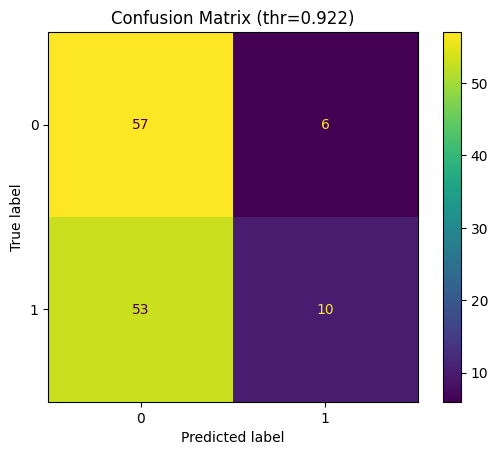

              precision    recall  f1-score   support

           0     0.5182    0.9048    0.6590        63
           1     0.6250    0.1587    0.2532        63

    accuracy                         0.5317       126
   macro avg     0.5716    0.5317    0.4561       126
weighted avg     0.5716    0.5317    0.4561       126



In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve

best_model = gs.best_estimator_
best_model.fit(X_train, y_train)

y_prob = best_model.predict_proba(X_val)[:, 1]
test_auc = roc_auc_score(y_val, y_prob)
print("Test AUC:", test_auc)

y_prob = best_model.predict_proba(X_val)[:, 1]

fpr, tpr, thr = roc_curve(y_val, y_prob)
thr_best = thr[np.argmax(tpr - fpr)]

chosen_thr = thr_best
y_pred = (y_prob >= chosen_thr).astype(int)

cm = confusion_matrix(y_val, y_pred, labels=[0,1])
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(values_format="d")
plt.title(f"Confusion Matrix (thr={chosen_thr:.3f})")
plt.show()

print(classification_report(y_val, y_pred, digits=4))